In [10]:
# Génération du dataset pour le mini-projet
import pandas as pd
import numpy as np

np.random.seed(2024)
n = 600

produits_info = {
    'Riz (1kg)':        (480, 80),
    'Huile (1L)':       (1150, 200),
    'Tomate (kg)':      (280, 120),
    'Plantain (kg)':    (320, 90),
    'Poulet (kg)':      (2400, 400),
    'Igname (kg)':      (450, 100),
    'Poisson fumé (kg)':(3600, 600),
    'Arachide (kg)':    (650, 120),
    'Manioc (kg)':      (180, 50),
    'Sucre (1kg)':      (580, 60),
}

marches = {
    'Mokolo':         'Douala',
    'Sandaga':        'Douala',
    'New-Bell':       'Douala',
    'Mfoundi':        'Yaoundé',
    'Mvog-Mbi':       'Yaoundé',
    'Marché Central': 'Yaoundé',
    'Marché Biyem':   'Yaoundé',
    'Grand Marché':   'Bafoussam',
}

data = []
for _ in range(n):
    prod = np.random.choice(list(produits_info.keys()))
    marche = np.random.choice(list(marches.keys()))
    ville = marches[marche]
    mu, sigma = produits_info[prod]
    mois = np.random.choice(['Jan','Fév','Mar','Avr','Mai','Jun'], p=[0.2,0.2,0.2,0.15,0.15,0.1])
    # Variation saisonnière
    coeff_saisonnier = 1.1 if mois in ['Avr','Mai'] else 0.95 if mois in ['Jan','Fév'] else 1.0
    prix = max(50, int(np.random.normal(mu * coeff_saisonnier, sigma)))
    qty  = np.random.randint(1, 100)
    collecteur = np.random.choice(['Enquêteur_A','Enquêteur_B','Enquêteur_C'])
    data.append({
        'mois':mois,'marche':marche,'ville':ville,'produit':prod,
        'prix_fcfa':prix,'quantite':qty,'total':prix*qty,'collecteur':collecteur
    })

df_projet = pd.DataFrame(data)

# Problèmes à découvrir par l'étudiant
df_projet.loc[np.random.choice(df_projet.index,20),'prix_fcfa'] = np.nan
df_projet.loc[np.random.choice(df_projet.index,5),'prix_fcfa']  = df_projet['prix_fcfa'] * 10
df_projet = pd.concat([df_projet, df_projet.sample(15,random_state=7)], ignore_index=True)

# Sauvegarder
df_projet.to_csv('prix_alimentaires_cameroun.csv', index=False, encoding='utf-8')
print(f"Dataset sauvegardé : {df_projet.shape}")
print(df_projet.head())

Dataset sauvegardé : (615, 8)
  mois          marche    ville        produit  prix_fcfa  quantite  total  \
0  Avr        New-Bell   Douala    Manioc (kg)      187.0        75  14025   
1  Avr  Marché Central  Yaoundé      Riz (1kg)      515.0        31  15965   
2  Fév    Marché Biyem  Yaoundé  Arachide (kg)      333.0        28   9324   
3  Mar  Marché Central  Yaoundé  Arachide (kg)      633.0        55  34815   
4  Mai    Marché Biyem  Yaoundé    Sucre (1kg)      505.0        98  49490   

    collecteur  
0  Enquêteur_C  
1  Enquêteur_C  
2  Enquêteur_C  
3  Enquêteur_A  
4  Enquêteur_C  


In [14]:
# 1. Audit complet : shape, types, NaN, doublons, valeurs impossibles
df_projet.shape

(615, 8)

In [3]:
print(f"le types des données du dataset est : {df_projet.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mois        615 non-null    object 
 1   marche      615 non-null    object 
 2   ville       615 non-null    object 
 3   produit     615 non-null    object 
 4   prix_fcfa   594 non-null    float64
 5   quantite    615 non-null    int64  
 6   total       615 non-null    int64  
 7   collecteur  615 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 38.6+ KB
le types des données du dataset est : None


In [7]:
print(f'les valeur Nan sont : {df_projet.isnull()}')
print(f'le nombre de valeur Nan est : {df_projet.isnull().sum()}')

les valeur Nan sont :       mois  marche  ville  produit  prix_fcfa  quantite  total  collecteur
0    False   False  False    False      False     False  False       False
1    False   False  False    False      False     False  False       False
2    False   False  False    False      False     False  False       False
3    False   False  False    False      False     False  False       False
4    False   False  False    False      False     False  False       False
..     ...     ...    ...      ...        ...       ...    ...         ...
610  False   False  False    False      False     False  False       False
611  False   False  False    False      False     False  False       False
612  False   False  False    False      False     False  False       False
613  False   False  False    False      False     False  False       False
614  False   False  False    False      False     False  False       False

[615 rows x 8 columns]
le nombre de valeur Nan est : mois           0
marche 

In [12]:
print(df_projet.duplicated())
print(f'les doublons dans le data set est : {df_projet.duplicated().sum()}')

0      False
1      False
2      False
3      False
4      False
       ...  
610     True
611     True
612     True
613     True
614     True
Length: 615, dtype: bool
les doublons dans le data set est : 15


In [13]:
print(df_projet.describe())

          prix_fcfa    quantite          total
count    594.000000  615.000000     615.000000
mean    1087.500000   49.921951   50644.747967
std     1877.382827   28.391064   72427.988032
min       50.000000    1.000000     370.000000
25%      336.250000   25.000000   11137.500000
50%      532.500000   50.000000   23956.000000
75%     1093.500000   75.000000   50181.500000
max    29390.000000   99.000000  421610.000000


In [18]:
print(f'les valeur impossible sur la quantité sont : {df_projet[df_projet["quantite"]<0]}')
print(f'les valeur impossible sur le prix sont : {df_projet[df_projet["prix_fcfa"]<0]}')

les valeur impossible sur la quantité sont : Empty DataFrame
Columns: [mois, marche, ville, produit, prix_fcfa, quantite, total, collecteur]
Index: []
les valeur impossible sur le prix sont : Empty DataFrame
Columns: [mois, marche, ville, produit, prix_fcfa, quantite, total, collecteur]
Index: []


In [21]:
#2. Nettoyage justifié : traitement NaN, outliers, doublons
median = df_projet['prix_fcfa'].median()
df_projet['prix_fcfa'] = df_projet['prix_fcfa'].fillna(median)

In [22]:
df_projet = df_projet.drop_duplicates()

In [23]:
Q1 = df_projet['prix_fcfa'].quantile(0.25)
Q3 = df_projet['prix_fcfa'].quantile(0.75)

IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

df_projet = df_projet[(df_projet['prix_fcfa'] >= borne_inf) & (df_projet['prix_fcfa'] <= borne_sup)]

In [24]:
#3. Analyse univariée de toutes les variables (distributions, skew, stats)
df_projet['ville'].value_counts()

ville
Yaoundé      243
Douala       193
Bafoussam     63
Name: count, dtype: int64

In [25]:
df_projet['produit'].value_counts()

produit
Manioc (kg)          69
Plantain (kg)        69
Huile (1L)           63
Igname (kg)          61
Riz (1kg)            59
Arachide (kg)        59
Tomate (kg)          52
Sucre (1kg)          50
Poulet (kg)          13
Poisson fumé (kg)     4
Name: count, dtype: int64

In [26]:
df_projet['prix_fcfa'].describe()

count     499.000000
mean      549.615230
std       367.946339
min        50.000000
25%       305.000000
50%       494.000000
75%       629.500000
max      2140.000000
Name: prix_fcfa, dtype: float64

In [27]:
df_projet['prix_fcfa'].skew()

np.float64(1.807806943796701)

<Axes: >

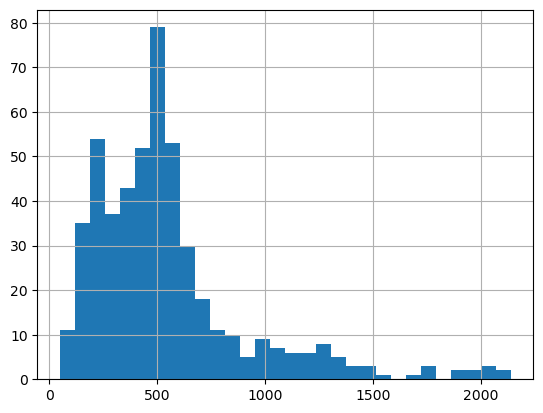

In [29]:
df_projet['prix_fcfa'].hist(bins = 30)

In [30]:
#4. Analyse bivariée : corrélations, boxplots par marché/ville
df_projet[['prix_fcfa','quantite','total']].corr()

,prix_fcfa,quantite,total
prix_fcfa,1.000000,0.005237,0.648994
quantite,0.005237,1.000000,0.533238
total,0.648994,0.533238,1.000000


<Axes: >

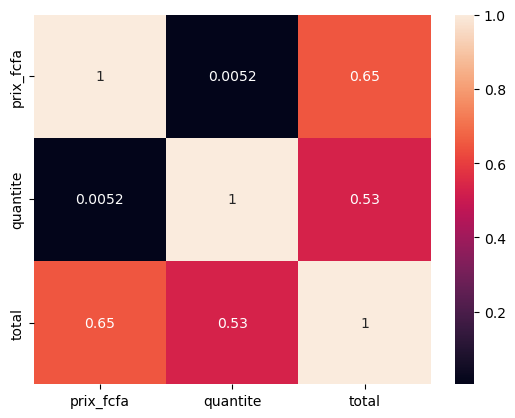

In [32]:
import seaborn as sns

sns.heatmap( df_projet[['prix_fcfa','quantite','total']].corr(), annot = True )

<Axes: xlabel='ville', ylabel='prix_fcfa'>

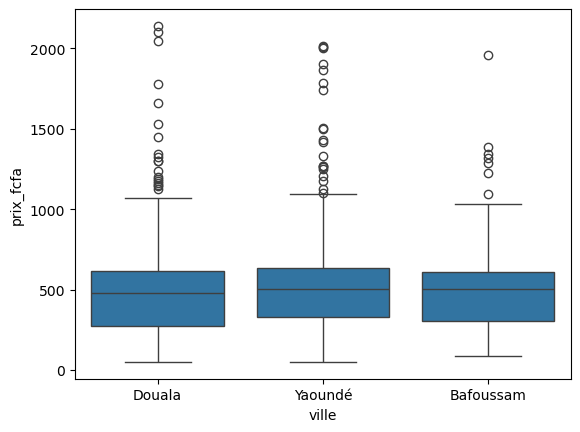

In [33]:
sns.boxplot(x='ville', y='prix_fcfa',data = df_projet)

<Axes: xlabel='marche', ylabel='prix_fcfa'>

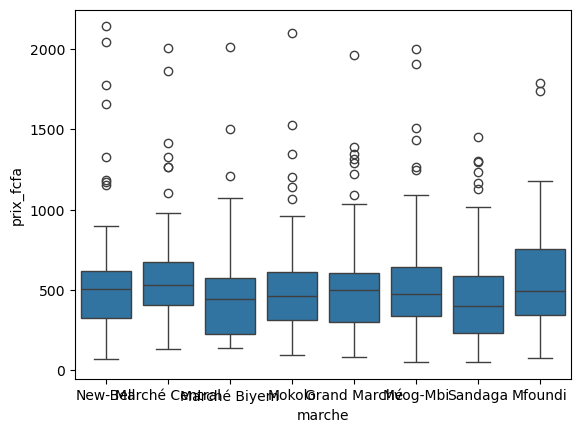

In [34]:
sns.boxplot(x='marche', y='prix_fcfa',data = df_projet)

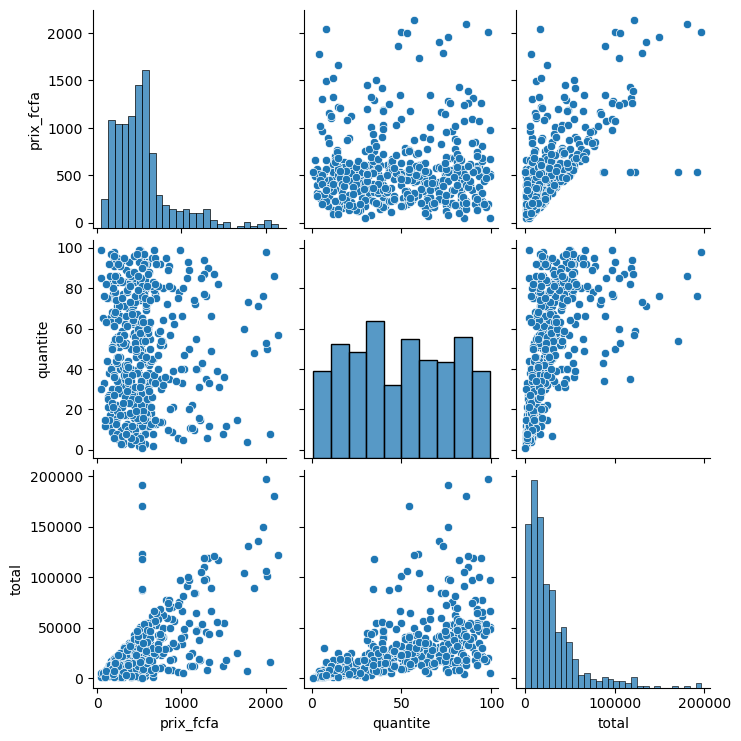

In [36]:
# 5. 	Analyse multivariée : pairplot, heatmap, segmentation
sns.pairplot( df_projet[['prix_fcfa','quantite','total']], diag_kind ='hist')

<Axes: >

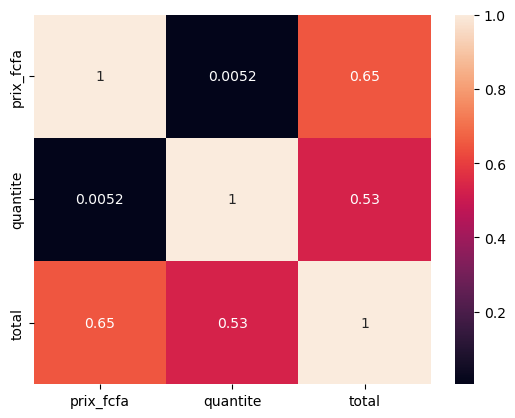

In [41]:
sns.heatmap(df_projet.corr(numeric_only=True), annot=True)

In [42]:
df_projet.groupby('ville')['prix_fcfa'].mean()

ville
Bafoussam    556.253968
Douala       539.217617
Yaoundé      556.152263
Name: prix_fcfa, dtype: float64

In [43]:
df_projet.groupby('produit')['prix_fcfa'].mean()

produit
Arachide (kg)         652.567797
Huile (1L)           1155.888889
Igname (kg)           468.057377
Manioc (kg)           204.471014
Plantain (kg)         339.695652
Poisson fumé (kg)     875.625000
Poulet (kg)          1535.461538
Riz (1kg)             485.559322
Sucre (1kg)           579.130000
Tomate (kg)           303.240385
Name: prix_fcfa, dtype: float64

In [47]:
#6. 3features engineerées avec justification (ratio, agrégation, tranche)
df_projet['prix_par_quantite'] = (df_projet['total'] / df_projet['quantite'])
print(df_projet['prix_par_quantite'])

0       187.0
1       515.0
2       333.0
3       633.0
4       505.0
        ...  
595     633.0
596     367.0
597     366.0
598    1326.0
599     476.0
Name: prix_par_quantite, Length: 499, dtype: float64


In [48]:
df_projet['tranche_prix'] = pd.cut(df_projet['prix_fcfa'], bins=[0,200,1500,5000], labels=['Bas','Moyen','Elevé'])
print(df_projet['tranche_prix'])

0        Bas
1      Moyen
2      Moyen
3      Moyen
4      Moyen
       ...  
595    Moyen
596    Moyen
597    Moyen
598    Moyen
599    Moyen
Name: tranche_prix, Length: 499, dtype: category
Categories (3, object): ['Bas' < 'Moyen' < 'Elevé']


In [49]:
moyenne_ville = (df_projet.groupby('ville')['prix_fcfa'].transform('mean'))
df_projet['prix_moyen_ville'] = moyenne_ville
print(df_projet['prix_moyen_ville'])

0      539.217617
1      556.152263
2      556.152263
3      556.152263
4      556.152263
          ...    
595    556.152263
596    556.253968
597    539.217617
598    539.217617
599    556.152263
Name: prix_moyen_ville, Length: 499, dtype: float64


#7. Rapport EDA final avec 5 hypothèses formulées pour la modélisation ML
le dataset contient de valeurs manquantes, des doublons et des valeurs aberantes artificielles. Mais après nettoyage les distributions deviennent plus cohéentes, les corrélations sont exploitables, et les variables catégorielles sont équilibrées

h1 : le prix dépend formtement du type de produit
h2 : la ville influence les prix alimentaires
h3 : les mois d'avril et mai augmentent les prix à cause de l'effet saisonnier
h4 : certains marchés présentent des comportements de prix spécifique
h5 : le total peut être prédit efficacement à partir soit du prix, soit de la quantité, soit de la ville ou soit du produit